# Fisher-Freeman-Halton Exact Test

This notebook implements the Fisher-Freeman-Halton exact test to compare two distributions across 5 categories of justice principles.

**Null Hypothesis (H₀):** The two distributions stem from the same population/process

**Alternative Hypothesis (H₁):** The two distributions stem from different populations/processes

In [18]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from scipy.stats.contingency import expected_freq
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import tempfile
import os
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

## Data Setup

Based on the original Frohlich & Oppenheimer study data:

In [19]:
# Data from the original study
# Categories: Max floor income, Max average income, Max average with floor constraint, 
#           Max average with range constraint, No Agreement

data = {
    'Principle': [
        'Max. floor income',
        'Max. average income', 
        'Max. average with floor constraint',
        'Max. average with range constraint',
        'No Agreement'
    ],
    'Frohlich_Oppenheimer': [5, 1, 23, 2, 7],
    'Replication_Study': [1, 4, 6, 0, 2]
}

df = pd.DataFrame(data)
print("Contingency Table:")
print(df)
print(f"\nTotal observations - Frohlich & Oppenheimer: {sum(df['Frohlich_Oppenheimer'])}")
print(f"Total observations - Replication Study: {sum(df['Replication_Study'])}")

# Create contingency table array
contingency_table = np.array([
    df['Frohlich_Oppenheimer'].values,
    df['Replication_Study'].values
])

print(f"\nContingency Table (array format):")
print(contingency_table)
print(f"Shape: {contingency_table.shape}")

Contingency Table:
                            Principle  Frohlich_Oppenheimer  Replication_Study
0                   Max. floor income                     5                  1
1                 Max. average income                     1                  4
2  Max. average with floor constraint                    23                  6
3  Max. average with range constraint                     2                  0
4                        No Agreement                     7                  2

Total observations - Frohlich & Oppenheimer: 38
Total observations - Replication Study: 13

Contingency Table (array format):
[[ 5  1 23  2  7]
 [ 1  4  6  0  2]]
Shape: (2, 5)


## Visualization

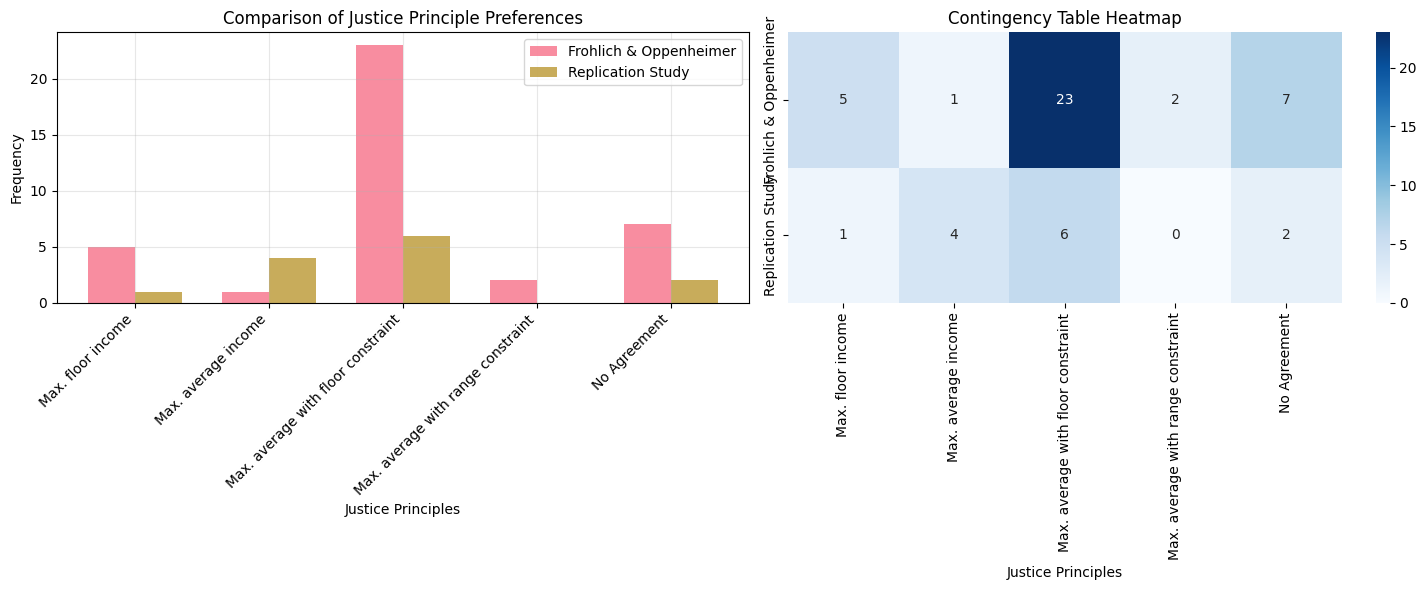

In [20]:
# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart comparison
x_pos = np.arange(len(df['Principle']))
width = 0.35

ax1.bar(x_pos - width/2, df['Frohlich_Oppenheimer'], width, 
        label='Frohlich & Oppenheimer', alpha=0.8)
ax1.bar(x_pos + width/2, df['Replication_Study'], width,
        label='Replication Study', alpha=0.8)

ax1.set_xlabel('Justice Principles')
ax1.set_ylabel('Frequency')
ax1.set_title('Comparison of Justice Principle Preferences')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df['Principle'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Heatmap
sns.heatmap(contingency_table, 
            xticklabels=df['Principle'],
            yticklabels=['Frohlich & Oppenheimer', 'Replication Study'],
            annot=True, 
            fmt='d',
            cmap='Blues',
            ax=ax2)
ax2.set_title('Contingency Table Heatmap')
ax2.set_xlabel('Justice Principles')

plt.tight_layout()
plt.show()

## Fisher-Freeman-Halton Exact Test

R's `fisher.test()` automatically implements the Fisher-Freeman-Halton exact test for r×c contingency tables. This is the gold standard for exact contingency table analysis:

In [21]:
def run_fisher_test_via_r(contingency_table):
    """Run Fisher-Freeman-Halton test using R via subprocess"""
    
    # Create R script content
    r_script = f"""
# Fisher-Freeman-Halton exact test
data <- matrix(c({', '.join(map(str, contingency_table.flatten()))}), nrow={contingency_table.shape[0]}, byrow=TRUE)

# Add labels
rownames(data) <- c("Frohlich_Oppenheimer", "Replication_Study")
colnames(data) <- c("Max_Floor", "Max_Average", "Max_Avg_Floor", "Max_Avg_Range", "No_Agreement")

# Print table
cat("Contingency Table in R:\\n")
print(data)
cat("\\n")

# Run Fisher's exact test
result <- fisher.test(data, workspace=2e6)
print(result)

# Output results in parseable format
cat("\\nP_VALUE:", result$p.value, "\\n")
cat("METHOD:", result$method, "\\n")
"""
    
    try:
        # Write R script to temporary file
        with tempfile.NamedTemporaryFile(mode='w', suffix='.R', delete=False) as f:
            f.write(r_script)
            temp_r_file = f.name
        
        # Run R script
        result = subprocess.run(['Rscript', temp_r_file], 
                              capture_output=True, text=True, timeout=60)
        
        if result.returncode == 0:
            print("R Output:")
            print(result.stdout)
            
            # Parse output
            output_lines = result.stdout.strip().split('\n')
            p_value = None
            method = None
            
            for line in output_lines:
                if line.startswith('P_VALUE:'):
                    p_value = float(line.split(':', 1)[1].strip())
                elif line.startswith('METHOD:'):
                    method = line.split(':', 1)[1].strip()
            
            return p_value, method, True
        else:
            print(f"R script failed: {result.stderr}")
            return None, None, False
            
    except subprocess.TimeoutExpired:
        print("R script timed out")
        return None, None, False
    except Exception as e:
        print(f"Error running R script: {e}")
        return None, None, False
    finally:
        # Clean up temporary file
        if 'temp_r_file' in locals():
            try:
                os.unlink(temp_r_file)
            except:
                pass

# Run Fisher-Freeman-Halton exact test via R
print("=== RUNNING FISHER-FREEMAN-HALTON EXACT TEST ===")
p_value_r, method_r, r_success = run_fisher_test_via_r(contingency_table)

if r_success:
    print(f"\n=== FISHER-FREEMAN-HALTON TEST RESULTS ===")
    print(f"Method: {method_r}")
    print(f"Exact p-value: {p_value_r:.6f}")
    print(f"Significance level (α = 0.05): {'Reject H₀' if p_value_r < 0.05 else 'Fail to reject H₀'}")
    
    # Store for later use
    exact_p_value = p_value_r
else:
    print("❌ R subprocess failed")
    exact_p_value = None

=== RUNNING FISHER-FREEMAN-HALTON EXACT TEST ===
R Output:
Contingency Table in R:
                     Max_Floor Max_Average Max_Avg_Floor Max_Avg_Range
Frohlich_Oppenheimer         5           1            23             2
Replication_Study            1           4             6             0
                     No_Agreement
Frohlich_Oppenheimer            7
Replication_Study               2


	Fisher's Exact Test for Count Data

data:  data
p-value = 0.07993
alternative hypothesis: two.sided


P_VALUE: 0.07992823 
METHOD: Fisher's Exact Test for Count Data 


=== FISHER-FREEMAN-HALTON TEST RESULTS ===
Method: Fisher's Exact Test for Count Data
Exact p-value: 0.079928
Significance level (α = 0.05): Fail to reject H₀


## Effect Size Analysis with Cramér's V

While the Fisher-Freeman-Halton test provides a reliable significance test, it does not quantify the strength of association. We calculate Cramér's V with bias-corrected bootstrap confidence intervals following Bergsma (2013):

In [22]:
def cramers_v(contingency_table):
    """Calculate Cramér's V"""
    chi2_stat = chi2_contingency(contingency_table)[0]
    n = np.sum(contingency_table)
    min_dim = min(contingency_table.shape) - 1
    return np.sqrt(chi2_stat / (n * min_dim))

def bias_corrected_cramers_v(contingency_table):
    """Calculate bias-corrected Cramér's V following Bergsma (2013)"""
    # Check for degenerate cases
    if np.any(np.sum(contingency_table, axis=0) == 0) or np.any(np.sum(contingency_table, axis=1) == 0):
        return 0.0
    if np.sum(contingency_table) <= 1:
        return 0.0
    
    try:
        chi2_stat = chi2_contingency(contingency_table)[0]
        n = np.sum(contingency_table)
        r, c = contingency_table.shape
        
        # Bias correction terms
        phi_squared = chi2_stat / n
        bias_correction = ((r - 1) * (c - 1)) / (n - 1)
        
        # Bias-corrected phi-squared
        phi_squared_corrected = max(0, phi_squared - bias_correction)
        
        # Bias-corrected Cramér's V
        min_dim = min(r - 1, c - 1)
        return np.sqrt(phi_squared_corrected / min_dim) if min_dim > 0 else 0
    except (ValueError, ZeroDivisionError):
        return 0.0

def bootstrap_cramers_v_pure(contingency_table, n_bootstrap=10000, confidence_level=0.95):
    """Pure bootstrap for Cramér's V - includes ALL samples, assigns V=0 to degenerate ones"""
    np.random.seed(42)
    
    # Create population from contingency table
    population = []
    for i in range(contingency_table.shape[0]):
        for j in range(contingency_table.shape[1]):
            population.extend([(i, j)] * contingency_table[i, j])
    
    population = np.array(population)
    n_total = len(population)
    
    bootstrap_vs = []
    degenerate_count = 0
    
    print(f"Running {n_bootstrap:,} bootstrap samples...")
    for b in range(n_bootstrap):
        if b % 2000 == 0:
            print(f"Progress: {b:,}/{n_bootstrap:,} ({b/n_bootstrap:.1%})")
            
        # Resample with replacement
        bootstrap_indices = np.random.choice(n_total, size=n_total, replace=True)
        bootstrap_sample = population[bootstrap_indices]
        
        # Create bootstrap contingency table
        bootstrap_table = np.zeros_like(contingency_table, dtype=int)
        for row, col in bootstrap_sample:
            bootstrap_table[row, col] += 1
        
        # Calculate Cramér's V for ALL samples
        v = bias_corrected_cramers_v(bootstrap_table)
        
        # Track degenerate cases
        if v == 0.0 and (np.any(np.sum(bootstrap_table, axis=0) == 0) or 
                         np.any(np.sum(bootstrap_table, axis=1) == 0)):
            degenerate_count += 1
        
        bootstrap_vs.append(v)
    
    print(f"Completed: {degenerate_count:,} degenerate samples (assigned V=0)")
    
    bootstrap_vs = np.array(bootstrap_vs)
    
    # Calculate confidence intervals
    alpha_ci = 1 - confidence_level
    lower_percentile = (alpha_ci / 2) * 100
    upper_percentile = (1 - alpha_ci / 2) * 100
    
    ci_lower = np.percentile(bootstrap_vs, lower_percentile)
    ci_upper = np.percentile(bootstrap_vs, upper_percentile)
    
    return bootstrap_vs, ci_lower, ci_upper, degenerate_count

# Calculate Cramér's V
print("=== EFFECT SIZE ANALYSIS ===")
cramers_v_standard = cramers_v(contingency_table)
cramers_v_corrected = bias_corrected_cramers_v(contingency_table)

print(f"Standard Cramér's V: {cramers_v_standard:.4f}")
print(f"Bias-corrected Cramér's V: {cramers_v_corrected:.4f}")

# Bootstrap confidence intervals
print(f"\nCalculating bootstrap confidence intervals (Bergsma, 2013)...")
bootstrap_values, ci_lower, ci_upper, degenerate_count = bootstrap_cramers_v_pure(contingency_table, n_bootstrap=10000)

print(f"\nBootstrap Results:")
print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Bootstrap mean: {np.mean(bootstrap_values):.4f}")
print(f"Bootstrap std: {np.std(bootstrap_values):.4f}")

# Effect size interpretation
if cramers_v_corrected < 0.1:
    effect_size = "negligible"
elif cramers_v_corrected < 0.3:
    effect_size = "small"
elif cramers_v_corrected < 0.5:
    effect_size = "medium"
else:
    effect_size = "large"

print(f"\nEffect Size: {effect_size} (V = {cramers_v_corrected:.4f})")

=== EFFECT SIZE ANALYSIS ===
Standard Cramér's V: 0.4237
Bias-corrected Cramér's V: 0.3154

Calculating bootstrap confidence intervals (Bergsma, 2013)...
Running 10,000 bootstrap samples...
Progress: 0/10,000 (0.0%)
Progress: 2,000/10,000 (20.0%)
Progress: 4,000/10,000 (40.0%)
Progress: 6,000/10,000 (60.0%)
Progress: 8,000/10,000 (80.0%)
Completed: 1,371 degenerate samples (assigned V=0)

Bootstrap Results:
95% Confidence Interval: [0.0000, 0.6338]
Bootstrap mean: 0.3065
Bootstrap std: 0.1990

Effect Size: medium (V = 0.3154)


## Final Summary

In [23]:
print("=== STATISTICAL REPORTING SUMMARY ===")

if 'exact_p_value' in locals() and exact_p_value is not None:
    print(f"Fisher-Freeman-Halton exact test: p = {exact_p_value:.6f}")
    
    if exact_p_value < 0.05:
        conclusion = "REJECT H₀: The distributions are significantly different"
    else:
        conclusion = "FAIL TO REJECT H₀: No significant difference found"
    
    print(f"Conclusion: {conclusion}")
    
    print(f"\nWhile the Fisher-Freeman-Halton test provides a reliable significance test")
    print(f"(p = {exact_p_value:.6f}), it does not quantify the strength of association.")
    print(f"Cramér's V = {cramers_v_corrected:.4f} (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])")
    print(f"indicates a {effect_size} effect size, facilitating comparison across studies.")
    print(f"Bias-corrected bootstrap confidence intervals address potential bias in sparse samples.")
else:
    print("Fisher-Freeman-Halton test could not be completed.")

# Sample diagnostics
print(f"\n=== SAMPLE DIAGNOSTICS ===")
print(f"Total sample size: {np.sum(contingency_table)}")
print(f"Table dimensions: {contingency_table.shape}")
print(f"Sparsity: {np.sum(contingency_table == 0) / contingency_table.size:.1%} (zero cells)")

=== STATISTICAL REPORTING SUMMARY ===
Fisher-Freeman-Halton exact test: p = 0.079928
Conclusion: FAIL TO REJECT H₀: No significant difference found

While the Fisher-Freeman-Halton test provides a reliable significance test
(p = 0.079928), it does not quantify the strength of association.
Cramér's V = 0.3154 (95% CI: [0.0000, 0.6338])
indicates a medium effect size, facilitating comparison across studies.
Bias-corrected bootstrap confidence intervals address potential bias in sparse samples.

=== SAMPLE DIAGNOSTICS ===
Total sample size: 51
Table dimensions: (2, 5)
Sparsity: 10.0% (zero cells)
